# CLN plus surface modes versus Foster: separating DC constraints from target bandwidth

Two questions are investigated:

1. Can surface enrichment reduce errors that persist when a short CLN is extended?
2. Can Foster achieve comparable transition-band accuracy and extend toward higher frequencies when DC error is allowed?

**High-band Foster fitting worked well here. Most improvement came from allocating accuracy to the target band; freeing DC added little.** Auxiliary surface-port enrichment reduced the measured error at a higher state count in a nonlinear circular rod. No equal-rank control establishes its superiority. These are distinct experiments.

| Experiment | Reference | What it tests |
|---|---|---|
| Linear circular section in a uniform transverse field | Analytic Bessel solution | DC, bandwidth, and truncation without FEM error |
| Notched 3D A–φ conductor | Full modal response of the same FE matrices | Reduction choices on two meshes |
| Nonlinear rod, FP-CLN plus surface basis | Full discrete FP solution on the same mesh/time step | Spatial-basis enrichment |

All results were recomputed. **Reciprocal Codex/Claude Opus 5.5 review is complete for the [recorded scope](REVIEW_STATUS.md).** Plot cells read stored data; instructions to rerun FEM, optimization, and time integration are below.


## Comparison conditions

Exactly converting the same reduced transfer function between Foster and Cauer forms does not change response accuracy. The choices compared here are retained fields, poles, target bands, and static constraints. [Otomo and Igarashi](https://eprints.lib.hokudai.ac.jp/dspace/bitstream/2115/79884/2/Final_ver_TPEL_Cauer-1.pdf) also describe Foster-to-Cauer conversion.

The fitted Foster model is

$$Z(u)=D+L_tu+\sum_{j=1}^{N}\frac{r_j u}{u+p_j},\quad p_j,r_j,D,L_t\geq0.$$

Poles are $-p_j$. Each relaxation term is a parallel RL branch impedance; nonnegative coefficients give a passive circuit.

The 3D reference is normalized magnetic reaction $Z(u)=u f^T(K+uM)^{-1}f$. Coordinates give static slope 1. DC preservation fixes $D=0$ and $L_t+\sum r_j/p_j=1$. This preserves a static reaction response, not the ordinary DC resistance of a wire.

Vary these factors separately:

- **Low-oriented band:** 0.1 Hz–30 kHz.
- **High-oriented band:** 1 kHz–1 MHz.
- **DC preserved:** fixed DC value and static slope.
- **DC free:** relax both constraints while fitting positive coefficients in-band.

Fitting uses 90 full-model samples, generated from a full generalized eigensystem and seeded from CLN/Galerkin models; optimiser timings exclude this offline reference generation. This is more information than single-point CLN receives. Band-aware multipoint CLN is a more relevant comparator, although it still uses fewer full solves. Fitting uses 90 points; evaluation uses a separate dense grid. Foster has four poles; single-point 3D CLN uses four magnetic-field bases, Type1 with eight elements and an R termination. Multipoint CLN also uses four total bases. Foster's static resistance/inductance terms are recorded separately, so the comparison does not impose identical total component or free-parameter counts.

Band-fitted Foster is not simply retention of four original eigenpoles. Positive energy-Galerkin models initialize optimization of poles and residues. Retained original eigenvectors permit field reconstruction, but a terminal-response fit alone does not establish it.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
root=Path.cwd()
if not (root/'validation').is_dir():
    root=root.parent
load=lambda name:json.loads((root/'docs/data'/name).read_text(encoding='utf-8'))
circle=load('foster_circle_controlled.json')
three=load('foster_3d_fine.json')
coarse=load('foster_3d_coarse.json')
fp=load('fp_surface_fine.json')
print('3D:',three['mesh'])
print('max error [%]: transition / 1kHz--1MHz')
for key in ['CLN single point rank 4','CLN multipoint band rank 4',
            'Foster fitted DC rank 4','Foster fitted high+DC rank 4','Foster fitted band rank 4']:
    item=three['runs'][key]
    print(f"{key:34s} {100*item['transition_max']:.6f} / {100*item['high_band_max']:.6f}")
print('DC-preserved high-band fit versus DC-free high-band fit is the controlled comparison.')
for dataset in [circle,three,coarse]:
    for key,item in dataset['runs'].items():
        assert np.all(np.isfinite(item['relative_error']))
        if key.startswith('Foster fitted'):
            assert item['optimizer_converged']
            assert all(p>0 for p in item['poles'])
            assert all(r>0 for r in item['residues'])
print('Fit status and coefficient checks passed')


3D: {'maxh': 0.003, 'ne': 1640, 'free_A': 3142, 'physical_dimension': 1399, 'gradient_dimension': 1743, 'kernel_load_fraction': 2.20733003815541e-14, 'static_H': 7.475644956885984e-05, 'reference_build_seconds': 5.161357400007546}
max error [%]: transition / 1kHz--1MHz
CLN single point rank 4            0.002444 / 1.065738
CLN multipoint band rank 4         0.024468 / 0.073595
Foster fitted DC rank 4            0.000212 / 1.429206
Foster fitted high+DC rank 4       0.015995 / 0.033601
Foster fitted band rank 4          0.038524 / 0.032514
DC-preserved high-band fit versus DC-free high-band fit is the controlled comparison.
Fit status and coefficient checks passed


## Transition and high-frequency regions

For the cylinder, $u=s\mu\sigma a^2$ and $\delta/a=\sqrt{2/|u|}$. The gray transition band is defined here by **$0.3\leq\delta/a\leq3$**, using the material and dimensions.

The 3D frequency grouping uses the same material and representative dimension $a=10$ mm. With a notch, this is not a universal transition criterion for every local dimension.

At the same high-frequency training band, freeing DC had little additional effect here. DC-preserving models can also allocate accuracy toward high frequencies. Conversely, retaining only the lowest original Foster eigenpoles is not always an accurate broadband approximation.


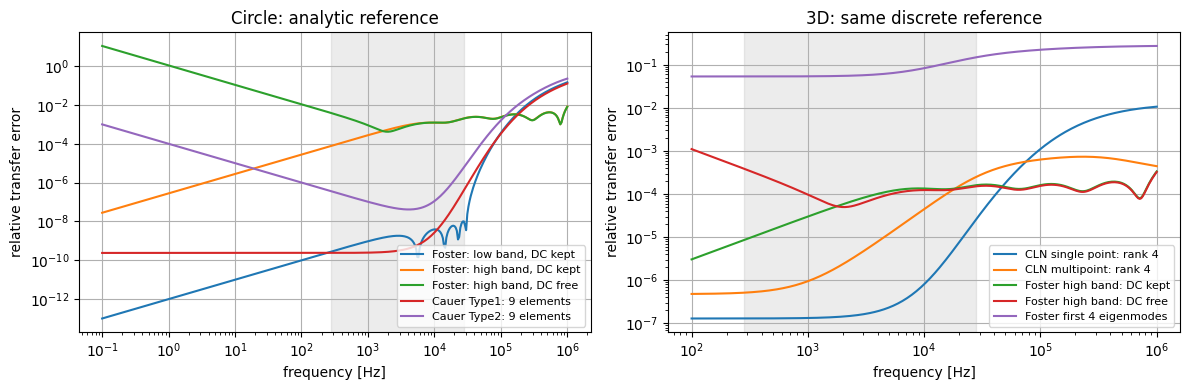

Circle controlled high-band comparison:
Foster fitted high+DC max error 0.00820860615054004 DC slope error 1.1102230246251565e-16 DC offset 0.0
Foster fitted band max error 0.008091025219132292 DC slope error 0.0008882085020776032 DC offset 0.0008667209323530656


In [2]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
labels={'Foster fitted DC':'Foster: low band, DC kept',
        'Foster fitted high+DC':'Foster: high band, DC kept',
        'Foster fitted band':'Foster: high band, DC free',
        'analytic CLN Type1 9 elements':'Cauer Type1: 9 elements',
        'analytic CLN Type2 9 elements':'Cauer Type2: 9 elements'}
for key,label in labels.items():
    axes[0].loglog(circle['frequency_hz'],np.maximum(circle['runs'][key]['relative_error'],1e-14),label=label)
labels3={'CLN single point rank 4':'CLN single point: rank 4',
         'CLN multipoint band rank 4':'CLN multipoint: rank 4',
         'Foster fitted high+DC rank 4':'Foster high band: DC kept',
         'Foster fitted band rank 4':'Foster high band: DC free',
         'Foster slow modes rank 4':'Foster first 4 eigenmodes'}
for key,label in labels3.items():
    axes[1].loglog(three['frequency_hz'],np.maximum(three['runs'][key]['relative_error'],1e-14),label=label)
for ax,d,title in zip(axes,[circle,three],['Circle: analytic reference','3D: same discrete reference']):
    f1=2/(3**2*2*np.pi*d['tau']); f2=2/(.3**2*2*np.pi*d['tau'])
    ax.axvspan(f1,f2,color='gray',alpha=.15)
    ax.set(xlabel='frequency [Hz]',ylabel='relative transfer error',title=title)
    ax.grid(True); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('Circle controlled high-band comparison:')
for k in ['Foster fitted high+DC','Foster fitted band']:
    v=circle['runs'][k]
    print(k,'max error',v['high_band_max'],'DC slope error',v['DC_slope_error'],'DC offset',v['DC_offset'])


## What the 3D experiment verifies

A 20×20×15 mm conductor has an upper-corner notch. Static potential and fields vary in three directions. Tangential A is constrained on the surface; φ is prescribed at the ends with natural conditions elsewhere. This is not a device model with exterior air and a return conductor.

Eliminating the A–φ scalar correction gives conductivity matrix $M_{AA}-D^TK_\phi^{-1}D$. After removing the curl gradient kernel, every model uses the same positive matrices $(K,M)$ and input $f$.

Type1 energy recurrences with shorted-port corrections generate the CLN basis. **The eight-element energy-derived circuit response is checked against Galerkin**, and an independently reorthogonalized Krylov span is checked as well. Symmetric eigenvalue solves and direct solves supply the validation reference; production ICCG is not silently replaced by another solver.

Diagonalizing the same reduced model gives a Foster form, so exact conversion alone produces no accuracy difference. Differences arise when selecting original eigenmodes or fitting a different band.

**High-frequency numbers are reduction errors against the same discrete model.** Mesh-to-mesh reference differences remain larger than the reduction errors. Small reduction error here is not continuum or device high-frequency accuracy.


In [3]:
for d in [coarse,three]:
    assert d['direct_reference_relative_difference']<1e-8
    print('mesh',d['mesh']['maxh'],'direct/modal difference',d['direct_reference_relative_difference'])
    for n in [4,8,12]:
        info=d['runs'][f'CLN single point rank {n}']
        assert info['circuit_elements_count']==2*n
        assert info['circuit_vs_ritz']<1e-6
        assert info['independent_span_response_difference']<1e-6
    print('CLN depth / independent rank:',[(x['requested'],x['independent_rank']) for x in d['depth_probe']])
zcoarse=np.asarray(coarse['reference_real'])+1j*np.asarray(coarse['reference_imag'])
zfine=np.asarray(three['reference_real'])+1j*np.asarray(three['reference_imag'])
print('max normalized reference difference between meshes:',np.max(abs(zcoarse/zfine-1)))
print('static response difference between meshes:',abs(coarse['mesh']['static_H']/three['mesh']['static_H']-1))


mesh 0.004 direct/modal difference 8.895505018787639e-16
CLN depth / independent rank: [(16, 16), (24, 24), (32, 32)]
mesh 0.003 direct/modal difference 1.7774914542289494e-15
CLN depth / independent rank: [(16, 16), (24, 24), (32, 32)]
max normalized reference difference between meshes: 0.03456172544280078
static response difference between meshes: 0.07190901525650528


## Which errors does surface enrichment reduce?

This is a separate **nonlinear 2D experiment**: radius 10 mm, $\sigma=2\times10^6$ S/m, initial relative permeability 200, saturation scale 1.5 T, and a 50 Hz transverse field.

CLN bases from the fixed FP kernel are combined with conductor extensions of additional surface Steklov ports. Exterior air is condensed onto the surface through an FE Schur complement. `surface="exact"` means **the full surface matrix of that discrete exterior model**, not an exact continuum solution.

The tested CLN models use 3–9 independent directions at 5–17 candidates. Auxiliary Steklov-mode loads, rather than the actual excitation alone, generate the enrichment blocks. Higher-angular auxiliary ports reduce the measured errors at ranks 19 and 55. This does not establish a CLN depth limit or an advantage over equal-rank multipoint/POD controls, which were not run. Most angular directions are inactive under the symmetry of this excitation; retained rank is not effective excited rank.

Output λ includes a condensed static-air term, so rod-reaction error excluding it is also recorded. Loss is the second-cycle integral $\sum\Delta t\,\dot A^TM\dot A$ from discrete conductor electric fields. Input work is reported separately using the trapezoidal rule. These two transient cycles do not establish periodic steady state or time-step convergence.

Candidates are normalized in the positive fixed linear energy metric and rank-checked by SVD. The 25- and 61-column candidate sets have independent ranks 19 and 55. Plots use retained ranks. Half of the original CLN candidates are structurally dependent electric-stage combinations; their dependence is not evidence of numerical breakdown.

This tests basis enrichment, not a direct contest between linear Foster and nonlinear FP-CLN. It does not guarantee that surface modes automatically resolve later-stage construction failures in every 3D implementation.


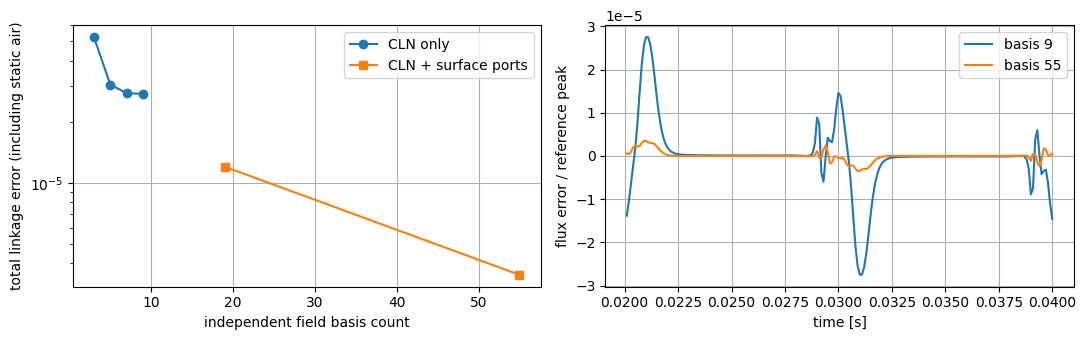

basis 9 flux error 2.751088847570405e-05 Joule-loss error 0.002258682397456434
basis 19 flux error 1.2003926697613118e-05 Joule-loss error 0.0017197851204848208
basis 55 flux error 3.515264822791728e-06 Joule-loss error 0.0006195900697831914
Unequal-rank total-linkage improvement (rank 9 vs 55, including static air): 7.826121177936075
Unequal-rank Joule-loss improvement (rank 9 vs 55): 3.6454464130562934
reference cycle change: 0.0011802483264219744
rod-only linkage error: 5.3687199967118625e-05
same full-model / same backward-Euler step reference; no continuum or time-step convergence claim


In [4]:
keys=list(fp['runs'])
ranks=[fp['runs'][k]['basis'] for k in keys]
errors=[fp['runs'][k]['max_rel_err'] for k in keys]
loss_errors=[fp['runs'][k]['joule_relative_error'] for k in keys]
fig,axes=plt.subplots(1,2,figsize=(11,3.5))
axes[0].semilogy(ranks[:4],errors[:4],'o-',label='CLN only')
axes[0].semilogy(ranks[4:],errors[4:],'s-',label='CLN + surface ports')
axes[0].set(xlabel='independent field basis count',ylabel='total linkage error (including static air)')
axes[0].grid(True); axes[0].legend()
t=np.asarray(fp['time']); ref=np.asarray(fp['reference']['lambda_trace'])
mask=t>1/fp['f']; scale=np.max(abs(ref[mask]))
for k in [keys[3],keys[-1]]:
    row=fp['runs'][k]
    axes[1].plot(t[mask],(np.asarray(row['lambda_trace'])[mask]-ref[mask])/scale,label=f"basis {row['basis']}")
axes[1].set(xlabel='time [s]',ylabel='flux error / reference peak')
axes[1].grid(True); axes[1].legend()
plt.tight_layout(); plt.show()
for k in [keys[3],keys[4],keys[5]]:
    row=fp['runs'][k]
    print('basis',row['basis'],'flux error',row['max_rel_err'],'Joule-loss error',row['joule_relative_error'])
assert errors[-1]<.5*errors[3]
assert loss_errors[-1]<loss_errors[3]
print('Unequal-rank total-linkage improvement (rank 9 vs 55, including static air):',errors[3]/errors[-1])
print('Unequal-rank Joule-loss improvement (rank 9 vs 55):',loss_errors[3]/loss_errors[-1])
print('reference cycle change:',fp['reference']['relative_cycle_change'])
print('rod-only linkage error:',fp['runs'][keys[-1]]['rod_linkage_relative_error'])
print('same full-model / same backward-Euler step reference; no continuum or time-step convergence claim')


## Reproduction

Code is in [validation/surface_hybrid](../validation/surface_hybrid/). It uses numpy, scipy, mpmath, and NGSolve for FEM. Run from the repository root.

```text
python validation/surface_hybrid/surface_modes_rod.py 3 0.2 docs/data/surface_circle.json
python validation/surface_hybrid/compare_circle.py --surface-results docs/data/surface_circle.json --output docs/data/foster_circle_controlled.json
python validation/surface_hybrid/compare_3d.py --maxh 0.004 --output docs/data/foster_3d_coarse.json
python validation/surface_hybrid/compare_3d.py --maxh 0.003 --output docs/data/foster_3d_fine.json
python validation/surface_hybrid/fp_cln_surface.py 2 0.3 docs/data/fp_surface_coarse.json
python validation/surface_hybrid/fp_cln_surface.py 2 0.2 docs/data/fp_surface_fine.json
python validation/surface_hybrid/validate_evidence.py
```

Self-review checks common inputs/outputs/matrices, static constraints, target bands, independent ranks, positive energy, circuit/field reduction responses, Foster equivalence, and fixed-point failure detection. Construction times are stored, but this small dense benchmark is not an industrial-scale 3D cost estimate.

**Finding:** band-targeted Foster is promising. Accuracy can shift toward high frequencies while preserving DC; freeing DC adds little here. Multipoint CLN also reduces high-frequency error. Auxiliary surface-port enrichment improved this symmetric nonlinear case at higher state count; equal-rank superiority has not been tested. These results do not establish superiority from Foster/Cauer representation alone.


## Rebuilt 3D comparison with the same physical excitation

[CLN, boundary response, and POD with a common excitation](08_3d_surface_pod_foster.ipynb) verifies that CLN and POD use the same physical source. It compares single/multipoint CLN and CLN2 plus physical-source boundary-response enrichment. The former conclusion based on substituting virtual boundary ports for the intended surface modes is withdrawn; boundary-response POD and Steklov modes are distinguished.


For executable exact Foster–Cauer round trips and the cited distinction between conversion, truncation, fitting and mesh error, see [Foster–Cauer conversion and error](09_foster_cauer_conversion_error.ipynb).

### Interpreting the DC constraint metric

For the DC-constrained Foster fits, the normalized static slope is fixed to one by construction. The recorded `DC_slope_error` in those cases measures constraint roundoff; it is not an independent check against measured DC data or an unnormalized target. The analytical and full discrete reference models supply the unit-slope normalization used in this experiment. For unconstrained fits, the slope is compared with that assumed unit reference. A different target requires its own independent DC reference.

### Rod reaction versus total linkage

The total-linkage denominator includes an exactly reproduced static-air contribution, which dilutes the relative error. The table below reports rod-only linkage error for every run alongside total linkage and conductor Joule loss. These are measured differences against the same discrete, time-discrete reference. Surface-enriched models have more states; a matched-rank control remains necessary before claiming superiority.

In [5]:
from pathlib import Path
import json
from IPython.display import display, Markdown
record_path = Path('docs/data/fp_surface_fine.json') if Path('docs/data').exists() else Path('data/fp_surface_fine.json')
record = json.loads(record_path.read_text(encoding='utf-8'))
rows = ['| Model | Retained rank | Rod linkage error [%] | Total linkage error [%] | Joule error [%] |','|---|---:|---:|---:|---:|']
for label, value in record['runs'].items():
    rows.append(f"| {label} | {value['basis']} | {100*value['rod_linkage_relative_error']:.6f} | {100*value['max_rel_err']:.6f} | {100*value['joule_relative_error']:.6f} |")
display(Markdown('\n'.join(rows)))

| Model | Retained rank | Rod linkage error [%] | Total linkage error [%] | Joule error [%] |
|---|---:|---:|---:|---:|
| FP-CLN n=5, surface=exact | 3 | 0.080063 | 0.005242 | 0.521111 |
| FP-CLN n=9, surface=exact | 5 | 0.046690 | 0.003057 | 0.333373 |
| FP-CLN n=13, surface=exact | 7 | 0.042275 | 0.002768 | 0.258981 |
| FP-CLN n=17, surface=exact | 9 | 0.042016 | 0.002751 | 0.225868 |
| multiport FP-CLN: port1 13 + Steklov ports [2, 3, 4, 5] x 3 | 19 | 0.018333 | 0.001200 | 0.171979 |
| multiport FP-CLN: port1 13 + Steklov ports [2, 3, 4, 5, 6, 7, 8, 9] x 6 | 55 | 0.005369 | 0.000352 | 0.061959 |